In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.integrate import simpson
from sklearn.metrics import r2_score

In [12]:
df = pd.read_csv("participant_data.csv")
df = df.melt(id_vars=['participant_id', 'Amount', 'Commodity'], var_name='delay', value_name='indifference_point')
df['delay'] = df['delay'].str.replace('delay_', '').astype(int)
df

,participant_id,Amount,Commodity,delay,indifference_point
0,1,100,Money,0,87.046932
1,2,100,Money,0,89.177107
2,3,100,Money,0,91.276222
3,4,100,Money,0,91.486833
4,5,100,Money,0,77.974339
...,...,...,...,...,...
2795,96,100,Money Loss,730,48.793758
2796,97,100,Money Loss,730,29.562199
2797,98,100,Money Loss,730,51.186185
2798,99,100,Money Loss,730,41.575091


In [7]:
# Hyperbolic: V = A / (1 + kD)
def hyperbolic(D, A, k):
    return A / (1 + k * D)

# Hyperboloid: V = A / ((1 + kD)^s)
def hyperboloid(D, A, k, s):
    return A / ((1 + k * D) ** s)

In [ ]:
# Add R² calculation to your fitting loop
fit_results = []

for (pid, amount, commodity), group in df.groupby(['participant_id', 'Amount', 'Commodity']):
    D = group['delay'].values
    V = group['indifference_point'].values
    A = amount  # Amount for this task
    
    # Fit hyperbolic
    try:
        popt_hyp, _ = curve_fit(lambda D, k: hyperbolic(D, A, k), D, V, bounds=(0, [10]))
        k_fit = popt_hyp[0]
        V_pred_hyp = hyperbolic(D, A, k_fit)
        r2_hyp = r2_score(V, V_pred_hyp)
    except:
        k_fit = np.nan
        r2_hyp = np.nan
    
    # Fit hyperboloid
    try:
        popt_hypb, _ = curve_fit(lambda D, k, s: hyperboloid(D, A, k, s), D, V, bounds=([0, 0], [10, 1]))
        k_fit_b = popt_hypb[0]
        s_fit_b = popt_hypb[1]
        V_pred_hypb = hyperboloid(D, A, k_fit_b, s_fit_b)
        r2_hypb = r2_score(V, V_pred_hypb)
    except:
        k_fit_b = np.nan
        s_fit_b = np.nan
        r2_hypb = np.nan
    
    # Calculate AUC (normalized delays and values)
    norm_D = (D - D.min()) / (D.max() - D.min()) if D.max() > D.min() else D
    norm_V = V / A
    auc = simpson(norm_V, norm_D)
    
    fit_results.append({
        'participant_id': pid,
        'Amount': amount,
        'Commodity': commodity,
        'k_hyperbolic': k_fit,
        'k_hyperboloid': k_fit_b,
        's_hyperboloid': s_fit_b,
        'AUC': auc,
        'r2_hyperbolic': r2_hyp,
        'r2_hyperboloid': r2_hypb
    })

fit_df = pd.DataFrame(fit_results)
fit_df

,participant_id,Amount,Commodity,k_hyperbolic,k_hyperboloid,s_hyperboloid,AUC,r2_hyperbolic,r2_hyperboloid
0,1,100,Food,0.006209,0.411217,0.171239,0.455352,0.276658,0.858442
1,1,100,Money,0.004470,0.243959,0.169452,0.500882,0.336458,0.847276
2,1,100,Money Loss,0.005719,0.363023,0.170630,0.466354,0.289018,0.855785
3,1,1000,Money,0.001745,0.440766,0.090551,0.649310,0.234344,0.997350
4,2,100,Food,0.004354,10.000000,0.087563,0.489220,-1.108751,0.601088
...,...,...,...,...,...,...,...,...,...
395,99,1000,Money,0.001957,1.094573,0.080909,0.636387,-0.032924,0.992825
396,100,100,Food,0.003644,2.178260,0.098915,0.550732,-0.286106,0.886483
397,100,100,Money,0.002690,1.145792,0.096527,0.593191,-0.183755,0.871233
398,100,100,Money Loss,0.003363,1.839948,0.098348,0.561569,-0.263765,0.882749


In [29]:
def plot_discounting_fits(df, fit_df, commodity, amount, n_participants=6, random_seed=42):
    """
    Plots discounting fits for a random sample of participants for a given commodity and amount.
    
    Parameters:
        df (pd.DataFrame): Raw data with columns including participant_id, Amount, Commodity, delay, indifference_point
        fit_df (pd.DataFrame): Fitted parameters with columns including participant_id, Amount, Commodity, k_hyperbolic, k_hyperboloid, s_hyperboloid, AUC
        commodity (str): The commodity/task to plot (e.g., 'Money', 'Money Loss', 'Food')
        amount (numeric): The amount to plot (e.g., 100, 1000)
        n_participants (int): Number of participants to plot (default 6)
        random_seed (int): Seed for reproducibility (default 42)
    """
    # Get all unique participant IDs for this task
    all_pids = fit_df[(fit_df['Commodity'] == commodity) & (fit_df['Amount'] == amount)]['participant_id'].unique()
    if len(all_pids) < n_participants:
        print(f"Only {len(all_pids)} participants found for {commodity} {amount}. Plotting all available.")
        n_participants = len(all_pids)
    np.random.seed(random_seed)
    pids = np.random.choice(all_pids, size=n_participants, replace=False)

    plt.figure(figsize=(15, 8))
    for i, pid in enumerate(pids):
        group = df[(df['participant_id'] == pid) & 
                   (df['Commodity'] == commodity) & 
                   (df['Amount'] == amount)]
        D = group['delay'].values
        V = group['indifference_point'].values
        A = group['Amount'].iloc[0]
        
        fit_row = fit_df[(fit_df['participant_id'] == pid) & 
                         (fit_df['Commodity'] == commodity) & 
                         (fit_df['Amount'] == amount)]
        k_h = fit_row['k_hyperbolic'].values[0]
        k_b = fit_row['k_hyperboloid'].values[0]
        s_b = fit_row['s_hyperboloid'].values[0]
        
        plt.subplot(2, 3, i+1)
        plt.scatter(D, V, label='Data')
        if not np.isnan(k_h):
            plt.plot(D, hyperbolic(D, A, k_h), label='Hyperbolic', linestyle='--')
        if not np.isnan(k_b) and not np.isnan(s_b):
            plt.plot(D, hyperboloid(D, A, k_b, s_b), label='Hyperboloid', linestyle=':')
        plt.title(f'P{pid}, {commodity}, {amount}')
        plt.xlabel('Delay')
        plt.ylabel('Value')
        plt.legend()
    plt.tight_layout()
    plt.show()

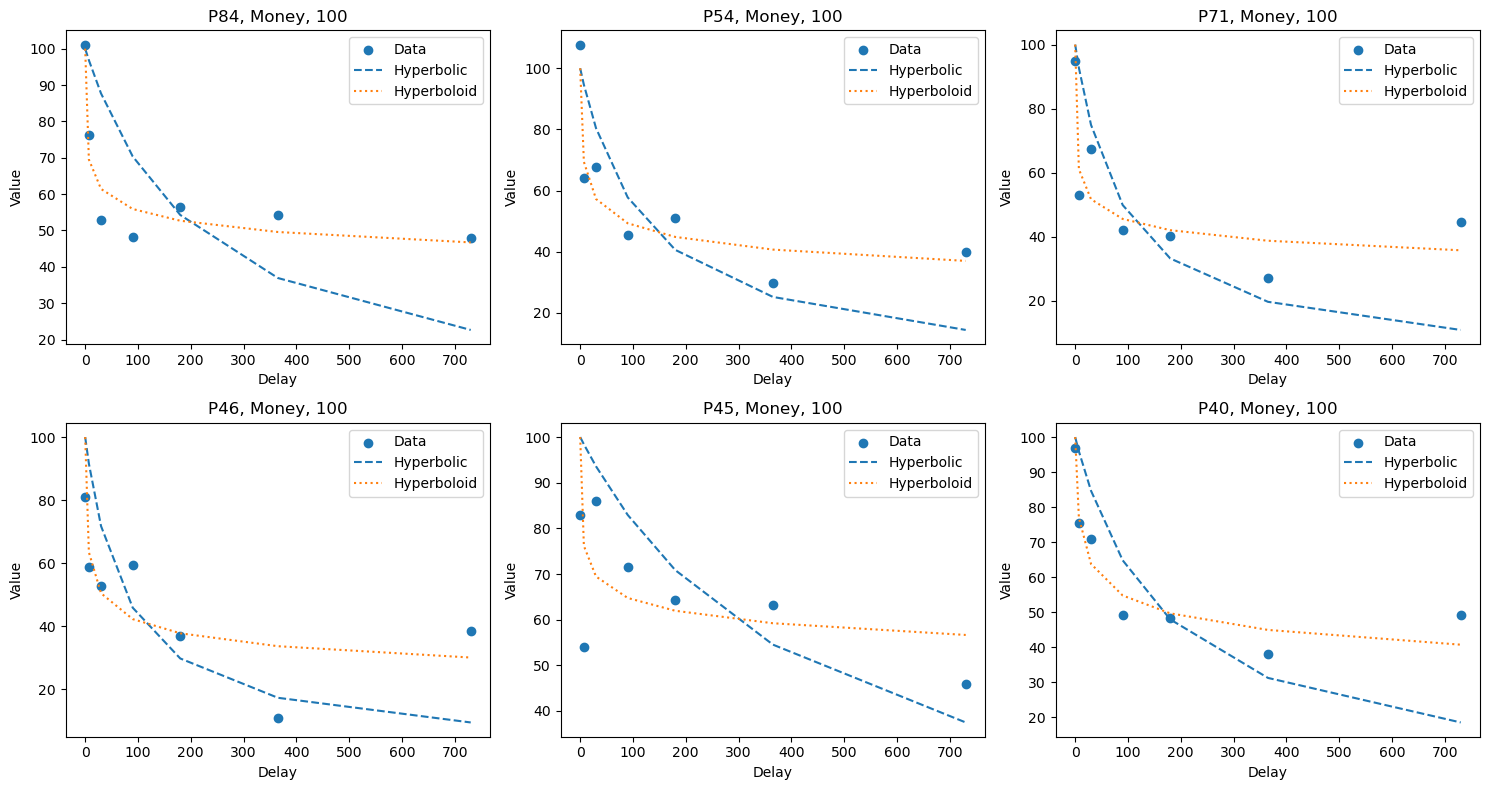

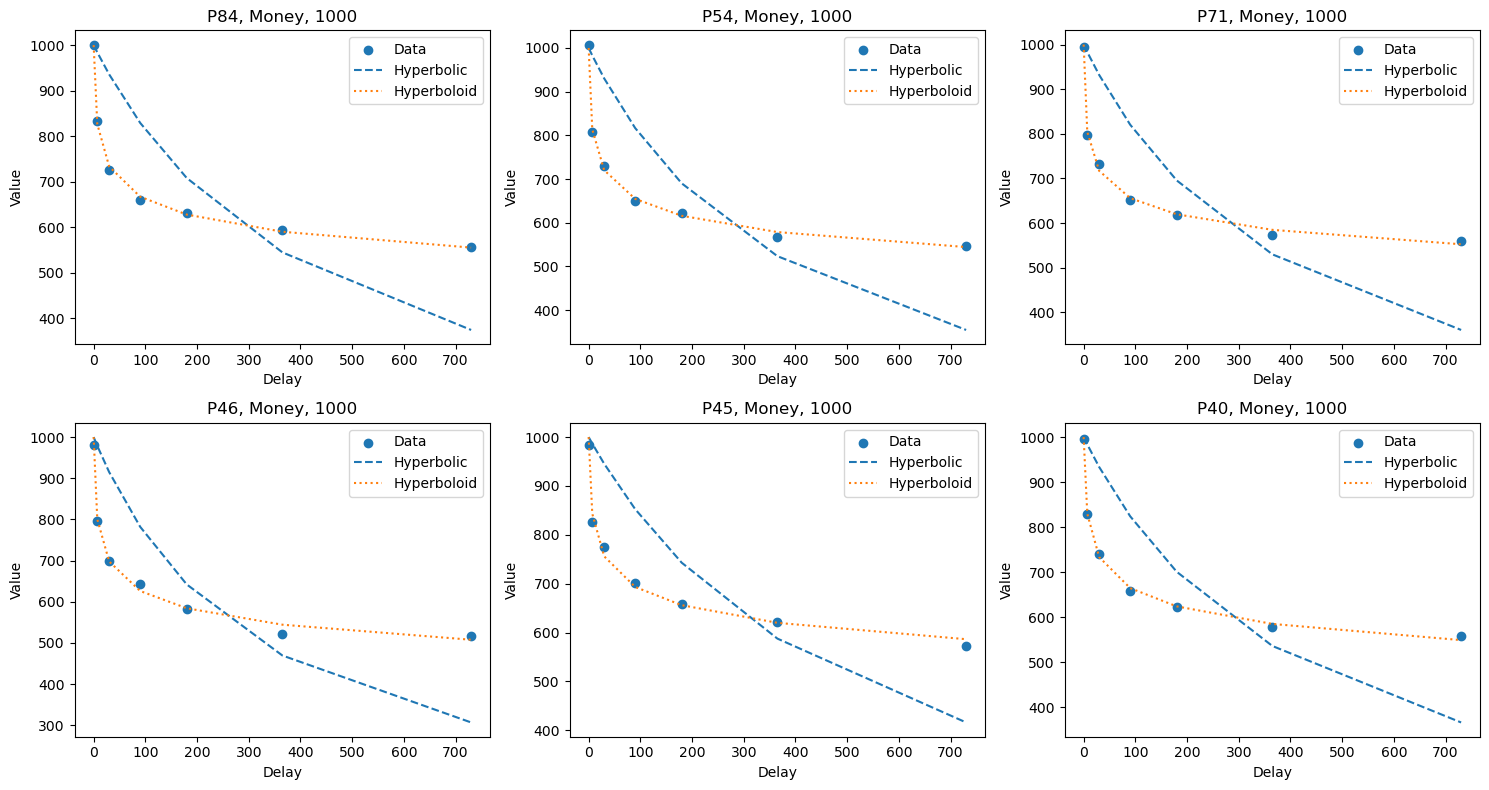

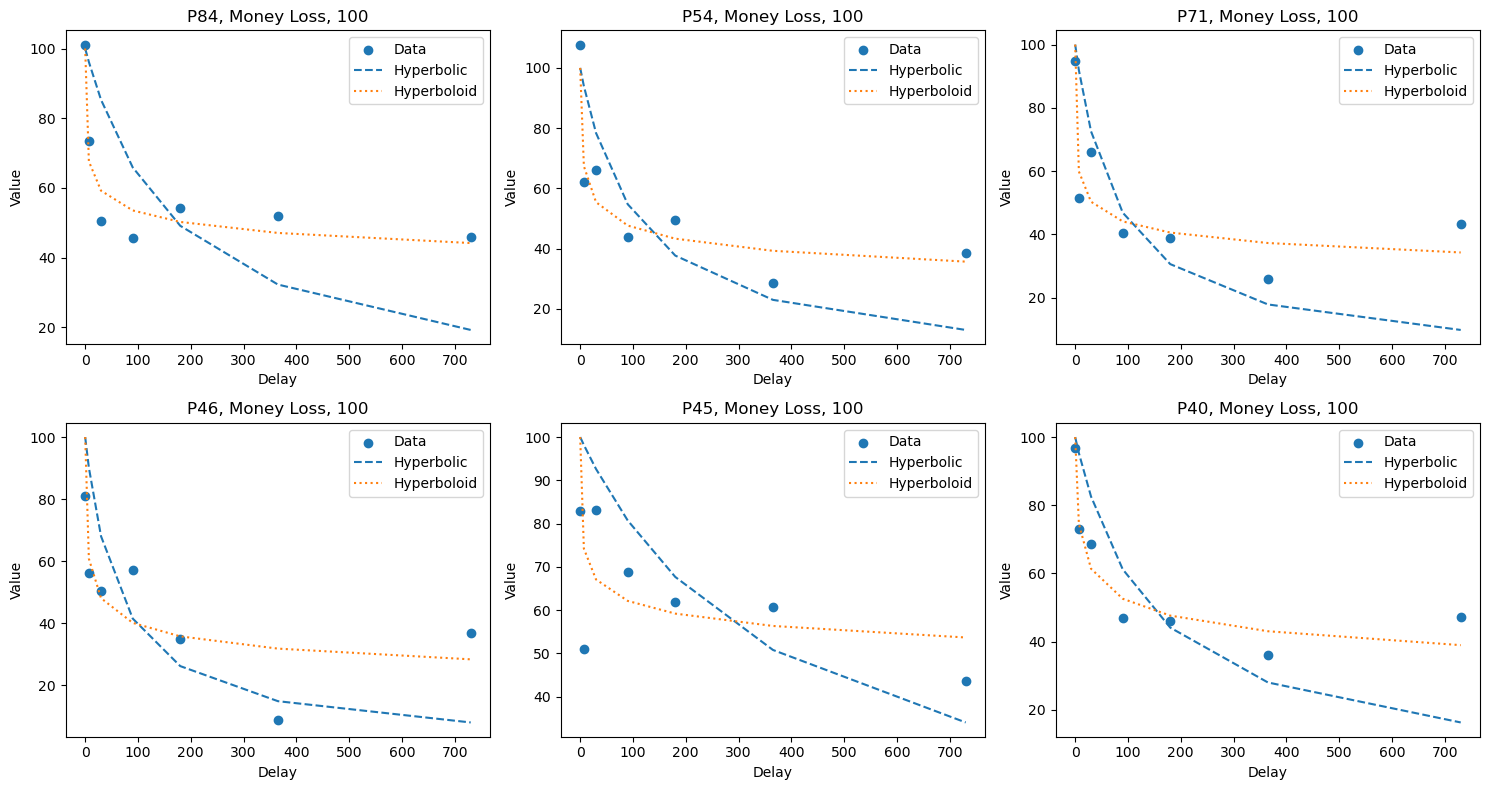

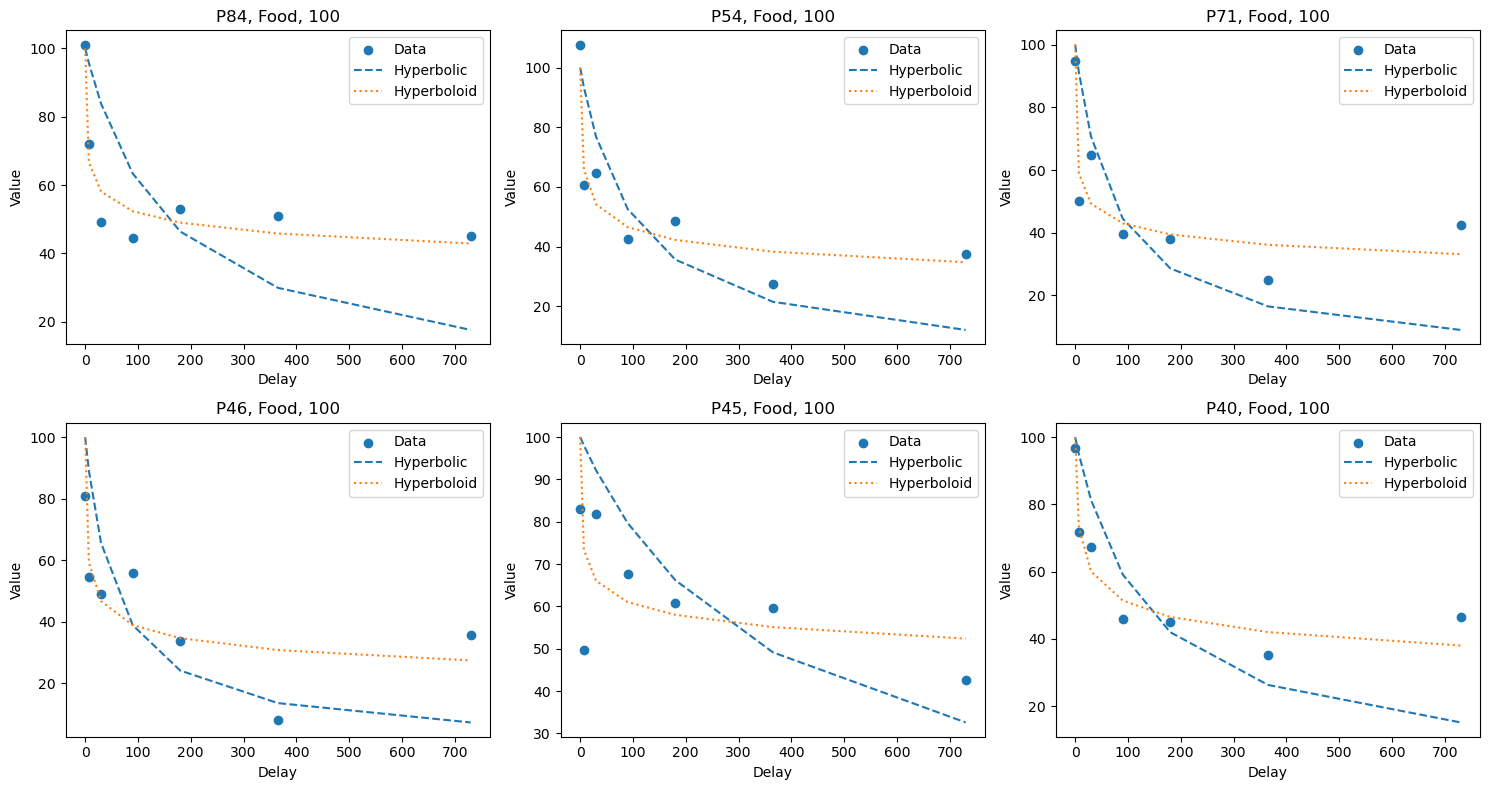

In [30]:
plot_discounting_fits(df, fit_df, commodity='Money', amount=100)
plot_discounting_fits(df, fit_df, commodity='Money', amount=1000)
plot_discounting_fits(df, fit_df, commodity='Money Loss', amount=100)
plot_discounting_fits(df, fit_df, commodity='Food', amount=100)

In [31]:
fit_df

,participant_id,Amount,Commodity,k_hyperbolic,k_hyperboloid,s_hyperboloid,AUC,r2_hyperbolic,r2_hyperboloid
0,1,100,Food,0.006209,0.411217,0.171239,0.455352,0.276658,0.858442
1,1,100,Money,0.004470,0.243959,0.169452,0.500882,0.336458,0.847276
2,1,100,Money Loss,0.005719,0.363023,0.170630,0.466354,0.289018,0.855785
3,1,1000,Money,0.001745,0.440766,0.090551,0.649310,0.234344,0.997350
4,2,100,Food,0.004354,10.000000,0.087563,0.489220,-1.108751,0.601088
...,...,...,...,...,...,...,...,...,...
395,99,1000,Money,0.001957,1.094573,0.080909,0.636387,-0.032924,0.992825
396,100,100,Food,0.003644,2.178260,0.098915,0.550732,-0.286106,0.886483
397,100,100,Money,0.002690,1.145792,0.096527,0.593191,-0.183755,0.871233
398,100,100,Money Loss,0.003363,1.839948,0.098348,0.561569,-0.263765,0.882749


/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_25881/3203850855.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x='Task', y='k', hue='Model', data=k_melt, dodge=True, color='k', alpha=0.4, jitter=True, marker='o')
/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_25881/3203850855.py:57: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x='Task', y='r2', hue='Model', data=r2_melt, dodge=True, color='k', alpha=0.4, jitter=True, marker='o')


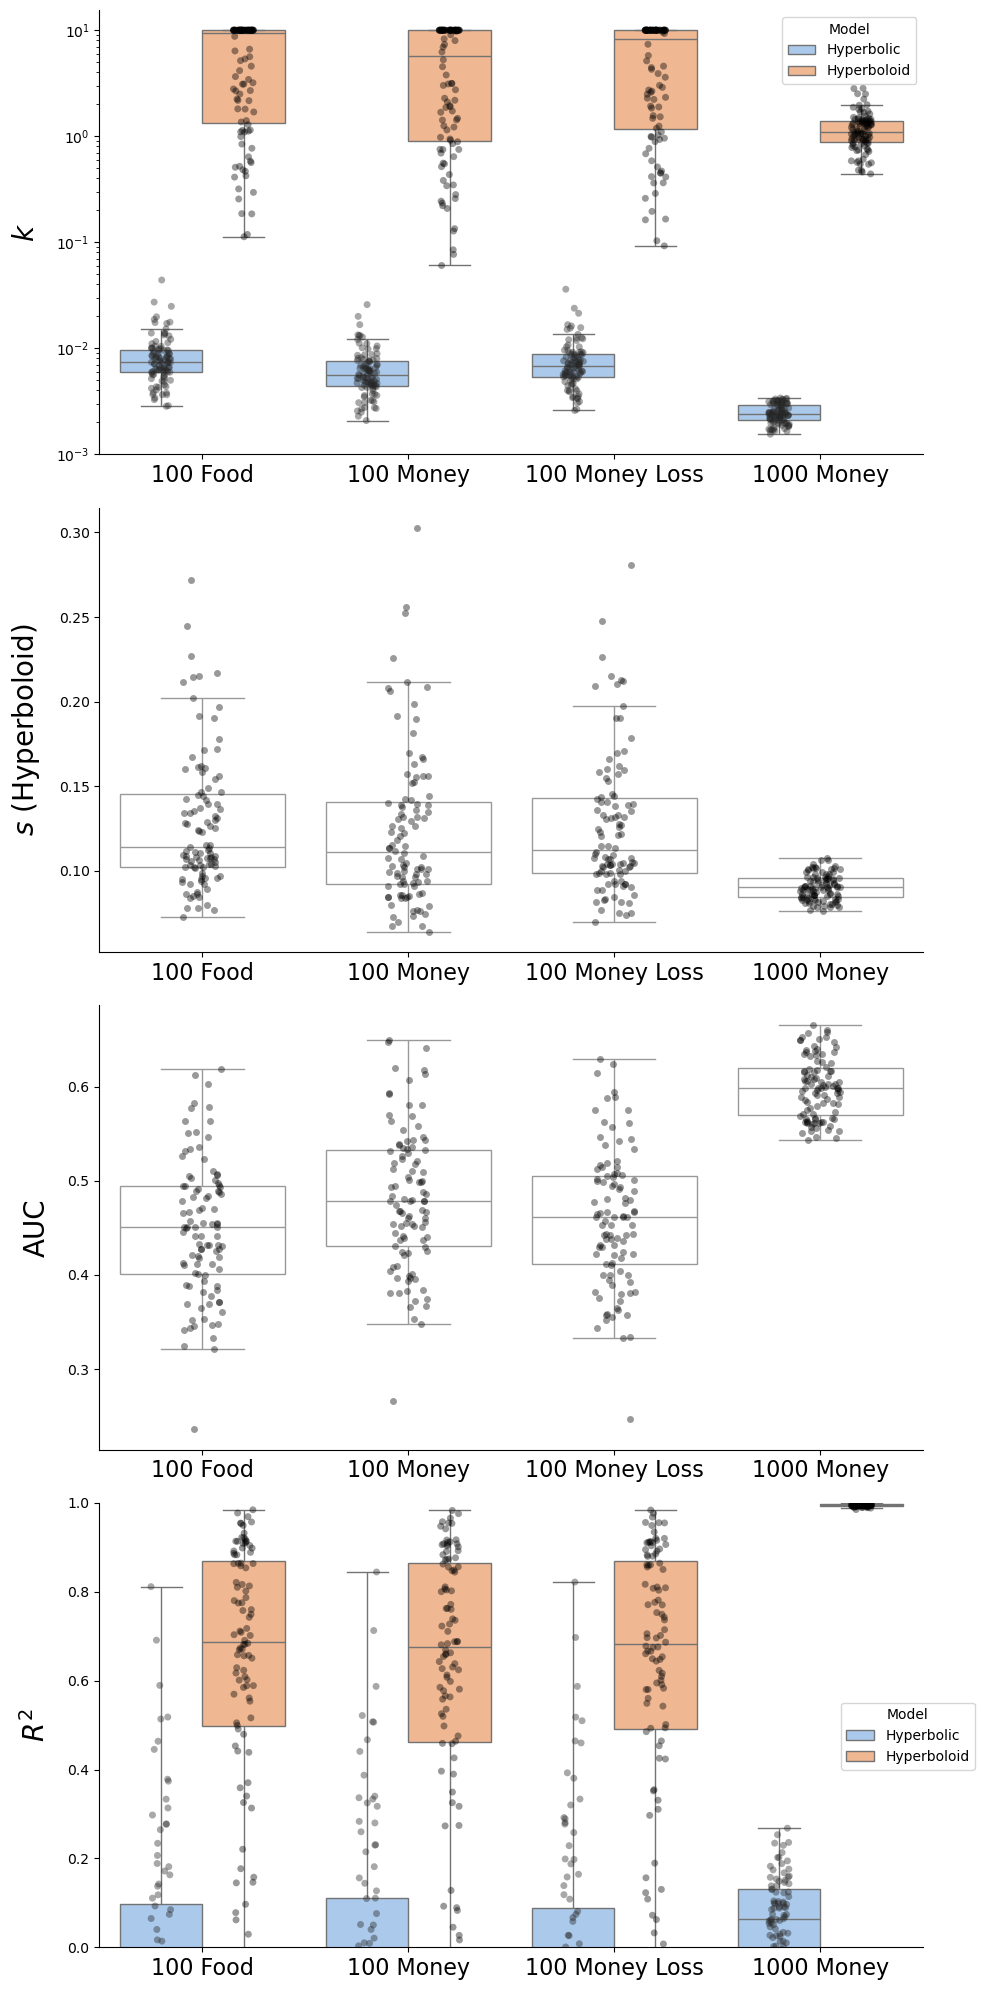

In [48]:
# Create a 'Task' column for x-axis
fit_df['Task'] = fit_df['Amount'].astype(str) + ' ' + fit_df['Commodity']

# Prepare data for k and r2 (melt for model comparison)
k_melt = pd.melt(
    fit_df,
    id_vars=['participant_id', 'Task'],
    value_vars=['k_hyperbolic', 'k_hyperboloid'],
    var_name='Model', value_name='k'
)
k_melt['Model'] = k_melt['Model'].map({'k_hyperbolic': 'Hyperbolic', 'k_hyperboloid': 'Hyperboloid'})

r2_melt = pd.melt(
    fit_df,
    id_vars=['participant_id', 'Task'],
    value_vars=['r2_hyperbolic', 'r2_hyperboloid'],
    var_name='Model', value_name='r2'
)
r2_melt['Model'] = r2_melt['Model'].map({'r2_hyperbolic': 'Hyperbolic', 'r2_hyperboloid': 'Hyperboloid'})

plt.figure(figsize=(10, 20))

# k comparison
plt.subplot(4, 1, 1)
sns.boxplot(x='Task', y='k', hue='Model', data=k_melt, showfliers=False, dodge=True, palette='pastel')
sns.stripplot(x='Task', y='k', hue='Model', data=k_melt, dodge=True, color='k', alpha=0.4, jitter=True, marker='o')
plt.ylabel(r'$k$', fontsize=20, labelpad=12)
plt.xlabel('', fontsize=20, labelpad=12)
plt.xticks(fontsize=16)
plt.legend(title='Model', loc='upper right')
sns.despine(top=True, right=True)
plt.yscale('log')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Model', loc='best')

# s_hyperboloid comparison
plt.subplot(4, 1, 2)
sns.boxplot(x='Task', y='s_hyperboloid', data=fit_df, showfliers=False, color='w')
sns.stripplot(x='Task', y='s_hyperboloid', data=fit_df, color='k', alpha=0.4, jitter=True, marker='o')
plt.ylabel(r'$s$ (Hyperboloid)', fontsize=20, labelpad=12)
plt.xlabel('', fontsize=20, labelpad=12)
plt.xticks(fontsize=16)
sns.despine(top=True, right=True)

# AUC comparison
plt.subplot(4, 1, 3)
sns.boxplot(x='Task', y='AUC', data=fit_df, showfliers=False, color='w')
sns.stripplot(x='Task', y='AUC', data=fit_df, color='k', alpha=0.4, jitter=True, marker='o')
plt.ylabel('AUC', fontsize=20, labelpad=12)
plt.xlabel('', fontsize=20, labelpad=12)
plt.xticks(fontsize=16)
sns.despine(top=True, right=True)

# r2 comparison
plt.subplot(4, 1, 4)
sns.boxplot(x='Task', y='r2', hue='Model', data=r2_melt, showfliers=False, dodge=True, palette='pastel')
sns.stripplot(x='Task', y='r2', hue='Model', data=r2_melt, dodge=True, color='k', alpha=0.4, jitter=True, marker='o')
plt.ylabel(r'$R^2$', fontsize=20, labelpad=12)
plt.xlabel('', fontsize=20, labelpad=12)
plt.xticks(fontsize=16)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.2))
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Model', loc=(0.9, 0.4))
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()